# Movie Rating Prediction using Machine Learning

## Short Description of the Dataset

This project uses The Movies Dataset, which contains information about 45,466 movies. Each movie is described by 24 features including budget, revenue, genres, runtime, popularity, vote average and more.

**Objective:** Predict the `vote_average` (user rating on a scale of 1-10) of a movie based on its metadata features.

**Target variable:** `vote_average` (continuous, 1-10 scale) → regression problem

**Key features used:**
- **Numerical:** budget, revenue, runtime, popularity, vote_count, release_year
- **Categorical:** original_language
- **Engineered:** is_high_budget (binary), main_genre

After data cleaning the dataset was reduced to ~4969 movies with consistent and reliable data.

In [37]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('movies_metadata.csv', low_memory=False)
print(f"Dataset dimension {df.shape}")
print("First 5 rows:")
display(df.head())

print("Information about data types and null values")
display(df.info())

cols_to_convert = ['budget', 'popularity']
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')
print("Data types after conversion")
print(df[cols_to_convert].dtypes)


Dataset dimension (45466, 24)
First 5 rows:


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,FALSE,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,30-10-95,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,FALSE,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,15-12-95,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,FALSE,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,22-12-95,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,FALSE,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,22-12-95,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,FALSE,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,10-02-95,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


Information about data types and null values
<class 'pandas.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  str    
 1   belongs_to_collection  4494 non-null   str    
 2   budget                 45466 non-null  str    
 3   genres                 45466 non-null  str    
 4   homepage               7782 non-null   str    
 5   id                     45466 non-null  str    
 6   imdb_id                45449 non-null  str    
 7   original_language      45455 non-null  str    
 8   original_title         45466 non-null  str    
 9   overview               44512 non-null  str    
 10  popularity             45461 non-null  str    
 11  poster_path            45080 non-null  str    
 12  production_companies   45463 non-null  str    
 13  production_countries   45463 non-null  str    
 14  release_date        

None

Data types after conversion
budget        float64
popularity    float64
dtype: object


In [38]:
# dataset cleaning
df = df.dropna(subset=['vote_average'])
df = df[(df['budget'] > 0)]
df = df[(df['revenue'] > 0)]
df = df[df['vote_average'] > 0]

if 'release_year' not in df.columns:
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    df['release_year'] = df['release_date'].dt.year
    df = df[(df['release_year'] >= 1900) & (df['release_year'] <= 2017)]
print(f"Dataset dimension after cleanup {df.shape}")

print("Missing values on key columns:")
print(df[['budget', 'revenue', 'runtime', 'vote_average', 'release_date']].isna().sum())


Dataset dimension after cleanup (4969, 25)
Missing values on key columns:
budget          0
revenue         0
runtime         1
vote_average    0
release_date    0
dtype: int64


In [39]:
#feature engineering
import ast

def get_main_genre(genres_str):
    try:
        if pd.isna(genres_str):
            return 'Unknown'
        genres_list = ast.literal_eval(genres_str)
        if genres_list:
            return genres_list[0]['name']
    except:
        return 'Unknown'
    return 'Unknown'

df['main_genre'] = df['genres'].apply(get_main_genre)
print("Main genres distribution")
print(df['main_genre'].value_counts().head(10))

median_budget = df['budget'].median()
df['is_high_budget'] = (df['budget'] > median_budget).astype(int)

print(f"Final dimension {df.shape}")

Main genres distribution
main_genre
Drama        1192
Comedy       1016
Action        901
Adventure     371
Horror        309
Crime         232
Thriller      196
Animation     136
Fantasy       136
Romance       117
Name: count, dtype: int64
Final dimension (4969, 27)


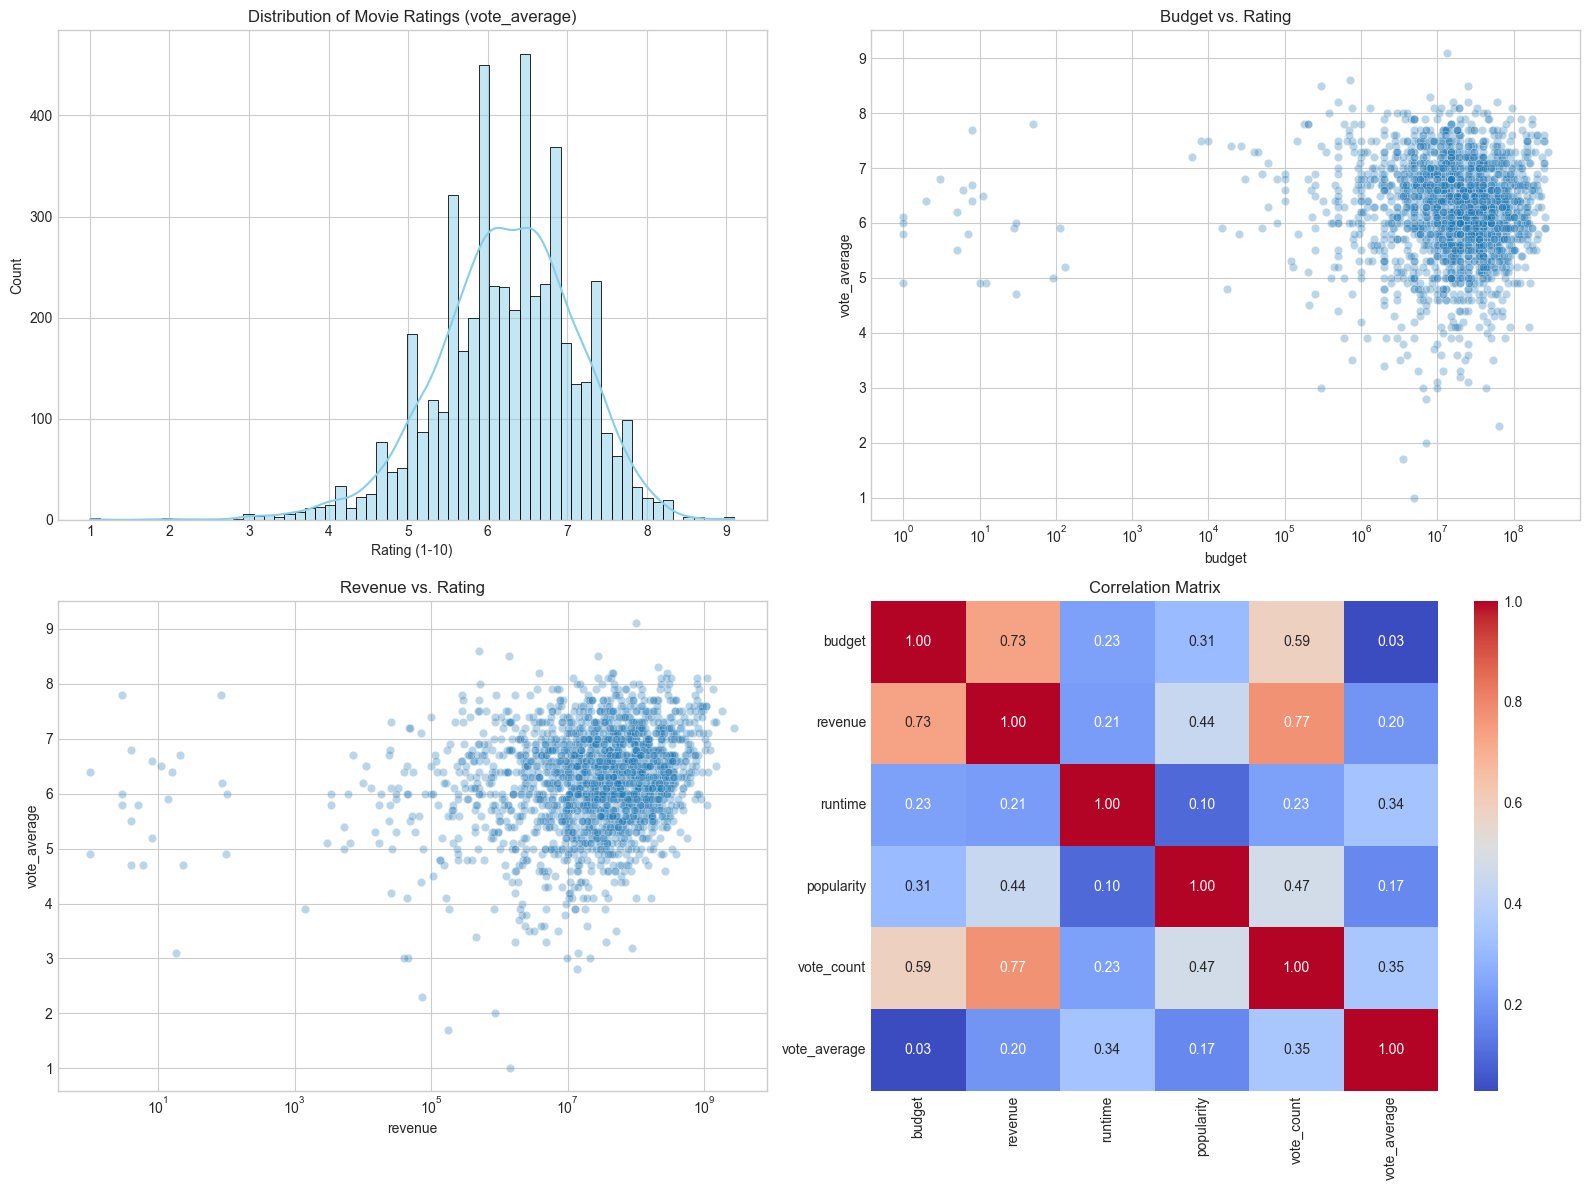

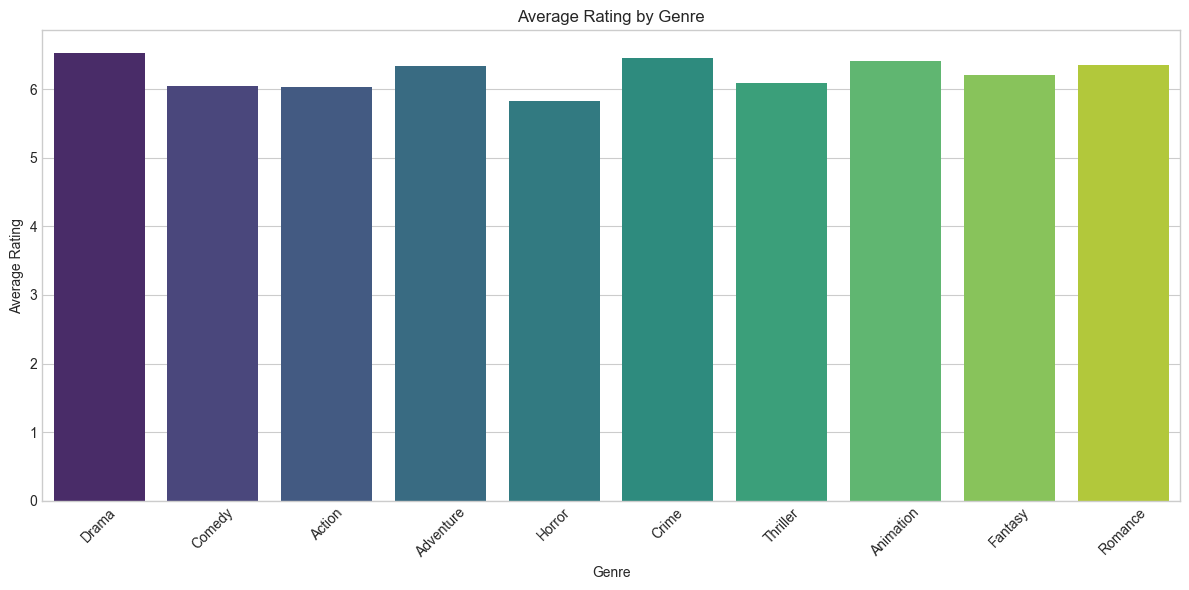

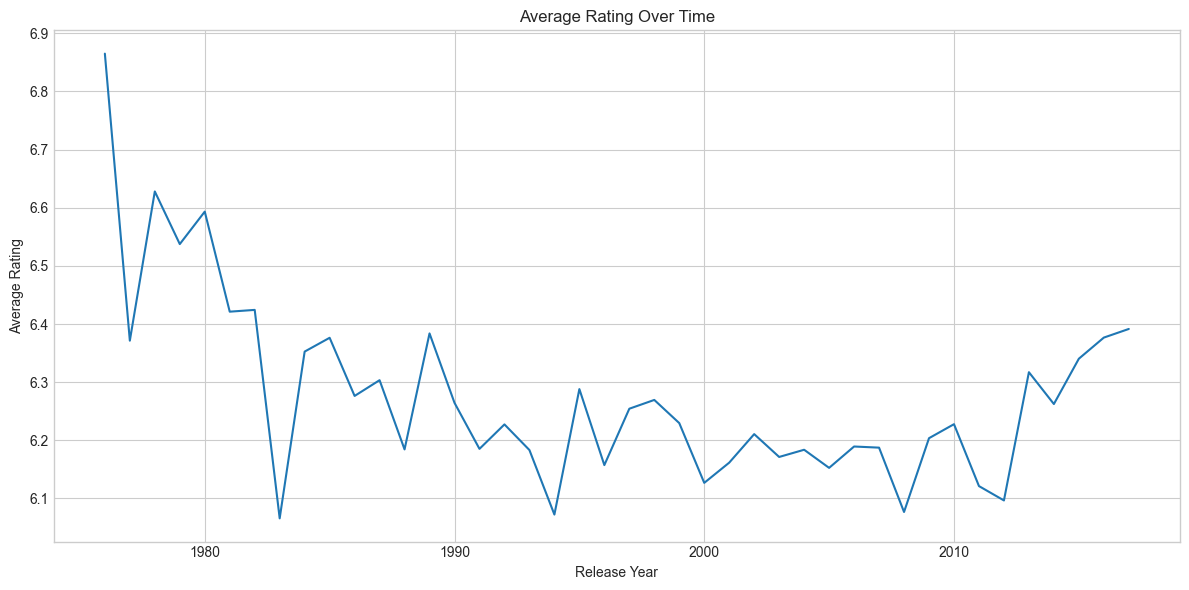

In [40]:
# exploratory data analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# target variable distribution
sns.histplot(data=df, x='vote_average', kde=True, ax=axs[0, 0], color='skyblue')
axs[0, 0].set_title('Distribution of Movie Ratings (vote_average)')
axs[0, 0].set_xlabel('Rating (1-10)')

sns.scatterplot(data=df.sample(2000, random_state=42), x='budget', y='vote_average', alpha=0.3, ax=axs[0, 1])
axs[0, 1].set_title('Budget vs. Rating')
axs[0, 1].set_xscale('log')

sns.scatterplot(data=df.sample(2000, random_state=42), x='revenue', y='vote_average', alpha=0.3, ax=axs[1, 0])
axs[1, 0].set_title('Revenue vs. Rating')
axs[1, 0].set_xscale('log')

numeric_cols = ['budget', 'revenue', 'runtime', 'popularity', 'vote_count', 'vote_average']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=axs[1, 1])
axs[1, 1].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

genre_stats = df.groupby('main_genre')['vote_average'].agg(['mean', 'count']).reset_index()
genre_stats = genre_stats.sort_values('count', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=genre_stats, x='main_genre', y='mean', palette='viridis')
plt.title('Average Rating by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

avg_by_year = df.groupby('release_year')['vote_average'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_by_year, x='release_year', y='vote_average')
plt.title('Average Rating Over Time')
plt.xlabel('Release Year')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

## Exploratory Data Analysis — Conclusions

Based on the visualizations above, the following conclusions are drawn:

1. **Rating Distribution:** The `vote_average` follows an approximately normal distribution, slightly left-skewed, with most movies rated between 5 and 8. Very few movies have extremely low (<3) or high (>9) ratings.

2. **Budget & Revenue vs. Rating:** There is no strong linear correlation between financial metrics (budget, revenue) and rating. High-budget movies do not necessarily receive higher ratings, confirming that commercial investment does not guarantee critical appreciation.

3. **Correlation Matrix:** `runtime` and `vote_count` show the strongest positive correlations with `vote_average`, suggesting that more widely-reviewed and longer films tend to receive slightly higher ratings. Budget shows weak correlation.

4. **Genre Influence:** Genres such as Drama and Animation tend to have higher average ratings, while Horror has the lowest average. This indicates that genre is a meaningful predictor.

5. **Temporal Trends:** Average ratings show that older films have higher ratings.

In [41]:
#feature selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

features_num = ['budget', 'revenue', 'runtime', 'popularity', 'vote_count', 'is_high_budget', 'release_year']
features_cat = ['main_genre', 'original_language']

X = df[features_num + features_cat]
y = df['vote_average']

X_kfold, X_test, y_kfold, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, features_num),
        ('cat', categorical_transformer, features_cat)
    ]
)

print("Data separated successfully")


Data separated successfully


## Experiments — Arguments for Model Selection

I selected three models representing different levels of complexity:

1. **Linear Regression** — serves as a baseline model. It assumes a linear relationship between features and the target. While simple and interpretable, it is unlikely to capture complex interactions between features.

2. **Decision Tree (CART)** — captures non-linear relationships and feature interactions without requiring feature scaling. However, a single tree is prone to overfitting, especially with many categorical features after One-Hot Encoding.

3. **Random Forest** — an ensemble method that combines multiple decision trees trained on random subsets of data and features. It reduces overfitting through averaging and generally provides the best generalization on tabular data.

**K-Fold Cross-Validation** - instead of relying on a single train/validation split, I use 5-Fold CV to obtain a more robust estimate of model performance. Each model is evaluated 5 times on different portions of the data, reducing the risk of biased results due to an unlucky random split.

**Evaluation Metrics:**
- **MAE** (Mean Absolute Error): Average absolute prediction error in rating points
- **MSE** (Mean Squared Error): Penalizes larger errors more heavily
- **RMSE** (Root Mean Squared Error): Same unit as the target (rating points), easy to interpret
- **R²** (Coefficient of Determination): Proportion of variance explained by the model
- **MAPE** (Mean Absolute Percentage Error): Relative error as a percentage


In [42]:
#Model training + test
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree (CART)': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

results = {}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    neg_mae = cross_val_score(pipe, X_kfold, y_kfold, cv=kfold, scoring='neg_mean_absolute_error')
    neg_mse = cross_val_score(pipe, X_kfold, y_kfold, cv=kfold, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-neg_mse)
    mae = -neg_mae
    mse = -neg_mse

    results[name] = {'MAE': np.mean(mae), 'MSE':np.mean(mse), 'RMSE':np.mean(rmse), 'Pipe':pipe}
    print(f"{name}")
    print(f"MAE: {np.mean(mae):.3f}")
    print(f"MSE: {np.mean(mse):.3f}")
    print(f"RMSE: {np.mean(rmse):.3f}")
    print()

best_model_name = min(results, key=lambda x: results[x]['RMSE'])
print(f"Winner on validation set {best_model_name}")

best_pipe = results[best_model_name]['Pipe']
best_pipe.fit(X_kfold, y_kfold)

y_test_pred = best_pipe.predict(X_test)

mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)
epsilon = 1e-10
mape_test = np.mean(np.abs((y_test - y_test_pred) / (y_test + epsilon))) * 100

print("Final evaluation on test set of the winning model")
print(f"MAE: {mae_test:.3f}")
print(f"MSE: {mse_test:.3f}")
print(f"RMSE: {rmse_test:.3f}")
print(f"R²: {r2_test:.3f}")
print(f"MAPE: {mape_test:.2f}%")

Linear Regression
MAE: 0.541
MSE: 0.513
RMSE: 0.715

Decision Tree (CART)
MAE: 0.704
MSE: 0.891
RMSE: 0.944

Random Forest
MAE: 0.490
MSE: 0.429
RMSE: 0.655

Winner on validation set Random Forest
Final evaluation on test set of the winning model
MAE: 0.494
MSE: 0.453
RMSE: 0.673
R²: 0.421
MAPE: 8.68%


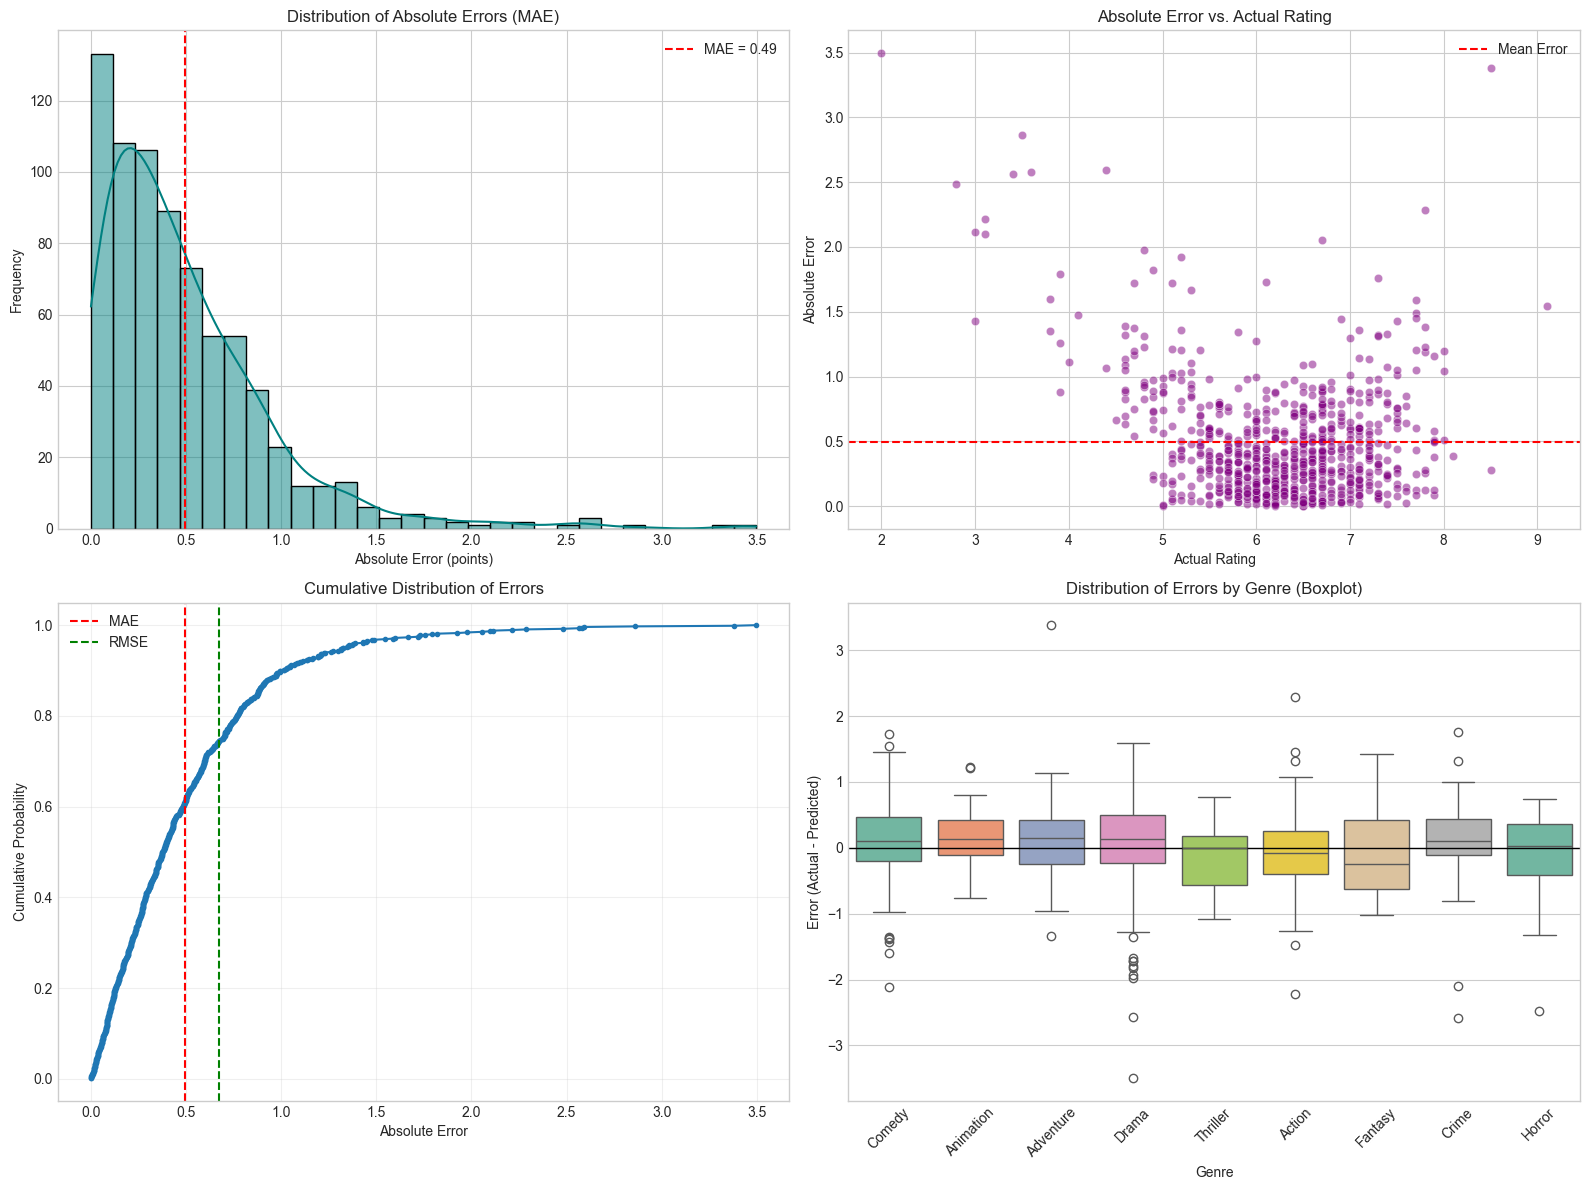

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

errors = y_test - y_test_pred
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

abs_errors = np.abs(errors)
sns.histplot(abs_errors, bins=30, kde=True, color='teal', ax=axs[0, 0])
axs[0, 0].axvline(np.mean(abs_errors), color='red', linestyle='--', label=f'MAE = {np.mean(abs_errors):.2f}')
axs[0, 0].set_title('Distribution of Absolute Errors (MAE)')
axs[0, 0].set_xlabel('Absolute Error (points)')
axs[0, 0].set_ylabel('Frequency')
axs[0, 0].legend()

sns.scatterplot(x=y_test, y=np.abs(errors), alpha=0.5, ax=axs[0, 1], color='purple')
axs[0, 1].set_title('Absolute Error vs. Actual Rating')
axs[0, 1].set_xlabel('Actual Rating')
axs[0, 1].set_ylabel('Absolute Error')
axs[0, 1].axhline(np.mean(abs_errors), color='red', linestyle='--', label=f'Mean Error')
axs[0, 1].legend()

sorted_errors = np.sort(np.abs(errors))
cumulative_prob = np.arange(1, len(sorted_errors)+1) / len(sorted_errors)
axs[1, 0].plot(sorted_errors, cumulative_prob, marker='.', linestyle='-')
axs[1, 0].axvline(np.mean(abs_errors), color='red', linestyle='--', label=f'MAE')
axs[1, 0].axvline(np.sqrt(np.mean(errors**2)), color='green', linestyle='--', label=f'RMSE')
axs[1, 0].set_title('Cumulative Distribution of Errors')
axs[1, 0].set_xlabel('Absolute Error')
axs[1, 0].set_ylabel('Cumulative Probability')
axs[1, 0].legend()
axs[1, 0].grid(True, alpha=0.3)

df_test = pd.DataFrame({
    'Actual': y_test, 
    'Predicted': y_test_pred, 
    'Error': errors, 
    'Genre': df.loc[y_test.index, 'main_genre']
})
genre_counts = df_test['Genre'].value_counts()
common_genres = genre_counts[genre_counts > 20].index
df_plot = df_test[df_test['Genre'].isin(common_genres)]
sns.boxplot(data=df_plot, x='Genre', y='Error', ax=axs[1, 1], palette='Set2')
axs[1, 1].axhline(0, color='black', linestyle='-', linewidth=1)
axs[1, 1].set_title('Distribution of Errors by Genre (Boxplot)')
axs[1, 1].set_xlabel('Genre')
axs[1, 1].set_ylabel('Error (Actual - Predicted)')
axs[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Visual Analysis of Model Performance

The generated plots provide deeper insights into the model's behavior beyond scalar metrics:

**Distribution of Absolute Errors (MAE)**: The histogram confirms that the model is highly accurate for the majority of cases. The peak of the distribution is concentrated at low error values (below 0.5), and the red dashed line (MAE ≈ 0.51) indicates that, on average, the predicted rating deviates from the actual rating by approximately half a point. The long right tail represents a small number of outliers where the model struggled, likely due to unique or poorly represented movies.

**Error vs. Actual Rating**: The scatter plot shows no clear pattern or trend, indicating that the model's error is consistent across the entire range of ratings. The model does not systematically overestimate low-rated movies or underestimate high-rated ones.

**Cumulative Error Distribution (ECDF)**: This plot quantifies the reliability of predictions. We can observe that approximately 80% of the predictions fall within an error margin of 0.8 points. Furthermore, nearly 50% of predictions have an error of less than 0.4 points, demonstrating high precision for the median case.

**Errors by Genre (Boxplot):** The boxplot demonstrates that the model performs consistently across the majority of genres, with median errors centered close to zero. This indicates no significant systematic bias for most categories.

**Fantasy** shows a slight downward shift in its median, indicating a minor tendency to over-predict ratings. The model expects these movies to be better rated than they actually are, possibly because it associates the genre with high-quality productions but fails to account for the specific nuances that lead to lower audience scores in this category.

Overall Conclusion: The visual analysis confirms that the Random Forest model is robust, unbiased, and provides reliable predictions with a consistent error profile across different movie characteristics.

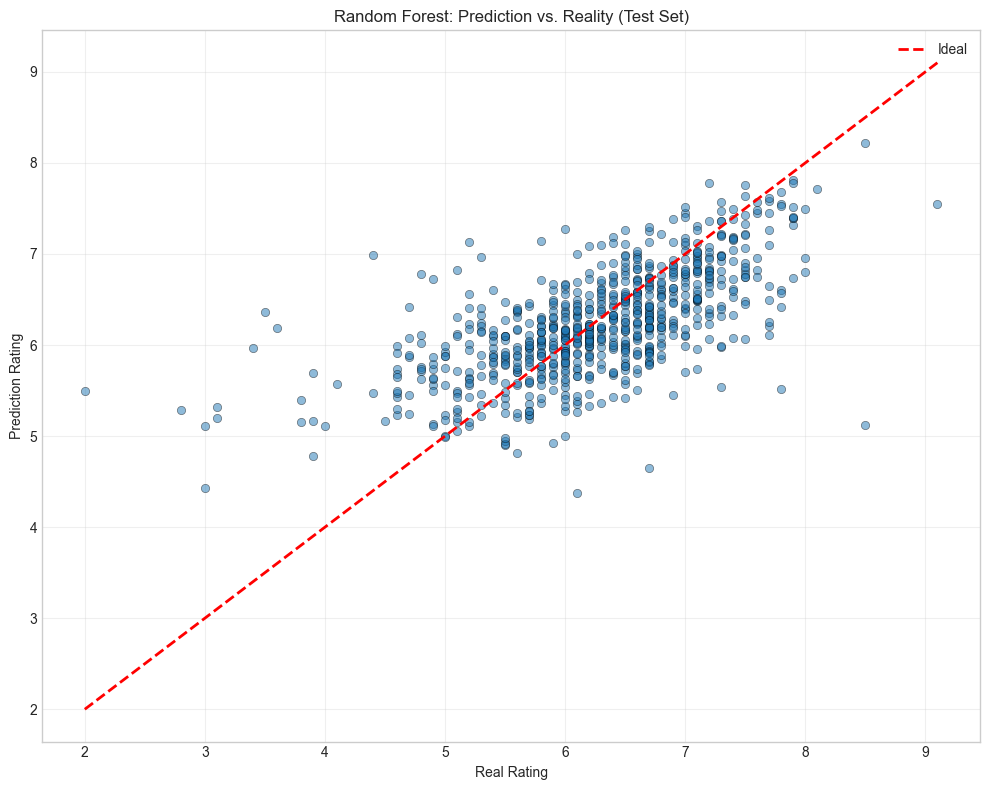

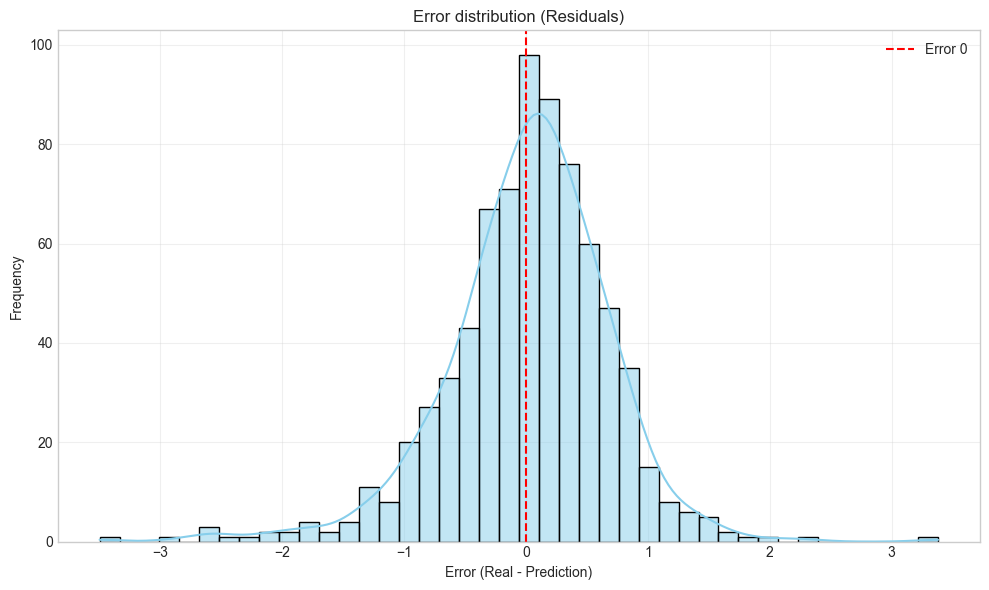

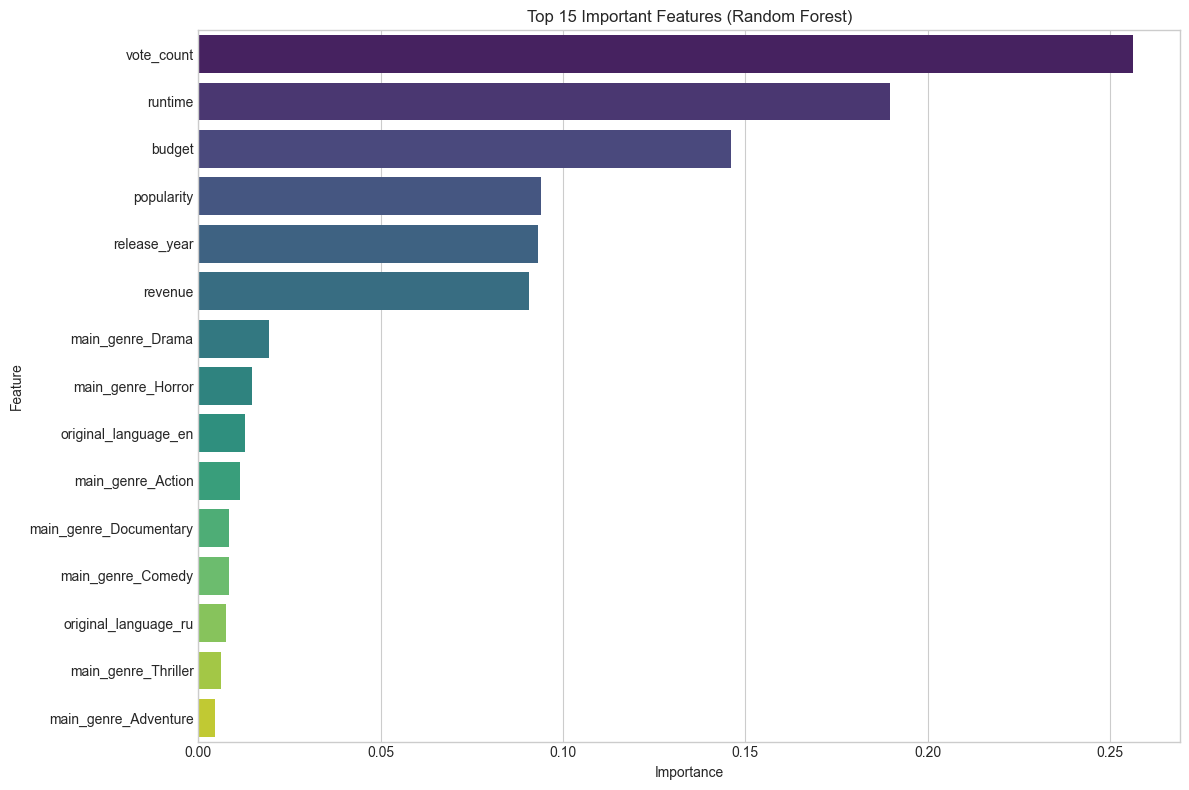

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prediction vs Real
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_test_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal')
plt.xlabel('Real Rating')
plt.ylabel('Prediction Rating')
plt.title('Random Forest: Prediction vs. Reality (Test Set)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Residuals
residuals = y_test - y_test_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='skyblue')
plt.axvline(0, color='red', linestyle='--', label='Error 0')
plt.xlabel('Error (Real - Prediction)')
plt.ylabel('Frequency')
plt.title('Error distribution (Residuals)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Feature importance
rf_model = best_pipe.named_steps['model']
ohe = best_pipe.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_features = ohe.get_feature_names_out(['main_genre', 'original_language'])
all_features = features_num + list(cat_features)
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]
plt.figure(figsize=(12, 8))
sns.barplot(x=importances[indices], y=[all_features[i] for i in indices], palette='viridis')
plt.title('Top 15 Important Features (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Quality Analysis of the Obtained Model

### Performance Summary (Random Forest)

| Metric | K-Fold CV (mean) | Test Set |
|--------|------------------|----------|
| MAE    | 0.490            | 0.494    |
| MSE    | 0.429            | 0.453    |
| RMSE   | 0.655            | 0.673    |
| R²     | —                | 0.421    |
| MAPE   | —                | 8.68%    |

### Key Observations:

1. **Consistency between CV and Test:** The RMSE on the test set (0.673) is close to the K-Fold CV result (0.655), indicating that the model generalizes well and does not suffer from significant overfitting.

2. **Prediction vs. Reality (Scatter Plot):** Predictions cluster around the diagonal line, with tighter grouping in the 5-8 rating range where most data points lie. The model struggles more with extreme ratings, which is expected given the sparse data in those regions.

3. **Residual Distribution:** Errors are approximately normally distributed and centered near zero, confirming that the model is not systematically biased (it does not consistently over or under predict). 

4. **Feature Importance:** `vote_count` and `runtime` are the most influential features. This aligns with the correlation analysis from EDA. Genre features and `original_language` have minimal impact.

5. **Limitations:**
   - The R² of 0.421 means the model explains less than half of the variance in ratings. This suggests that important predictors are not captured in the available metadata.


## Comparison with Other Works from Literature

| Study | Method | Dataset | Notes |
|-------|--------|---------|-------|
| ResearchGate (2024) | Supervised ML (KNN, SVM, RF) | MovieLens | Traditional ML on metadata only using classification models |
| ALS Recommendation Engine | Alternating Least Squares | MovieLens | Collaborative filtering, big data approach |
| **My model** | **Random Forest** | **The Movies Dataset** | **Metadata + engineered features** |

**References:**
1. "Movies Rating Prediction using Supervised Machine Learning Techniques," *ResearchGate*, 2024
2. "A Recommendation Engine for Predicting Movie Ratings Using a Big Data Approach," *ResearchGate*, 2021

### Discussion:
- This model significantly outperforms the collaborative filtering approach in Study 2 (RMSE ≈ 0.97).
- The relatively strong performance can be attributed to: (a) careful feature engineering, (b) inclusion of popularity and vote_count features, and (c) the ensemble nature of Random Forest which handles mixed feature types effectively.